In [1]:
pip install inference-sdk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.12.0.88
    Uninstalling opencv-python-4.12.0.88:
      Successfully uninstalled opencv-python-4.12.0.88
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.11.15
    Uninstalling aiohttp-3.11.15:
      Successfully uninstalled aiohttp-3.11.15


HTTPCallErrorError: HTTPCallErrorError(description='400 Client Error: Bad Request for url: https://serverless.roboflow.com/model/registry?api_key=poXcqijmjIAjyhnYTqob', api_message='Content-Type header not provided with request.',status_code=400)

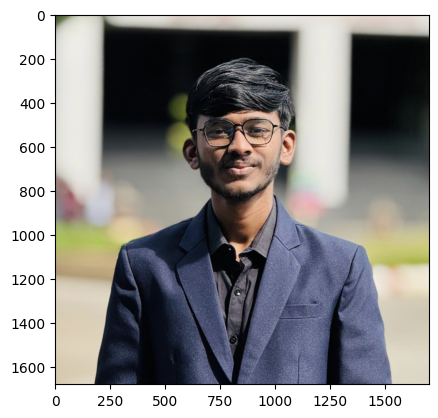

In [2]:
from inference_sdk import InferenceHTTPClient
import matplotlib.pyplot as plt


CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="poXcqijmjIAjyhnYTqob"
)
your_image = 'D:\Drone Surveillance System\Inference Engine\lost_person\image1.jpg'
plt.imshow(plt.imread(your_image))

result = CLIENT.infer(your_image, model_id="crowd-density-estimation/3")

In [1]:
print(result)

NameError: name 'result' is not defined

In [ ]:
print(len(result['predictions']))

300


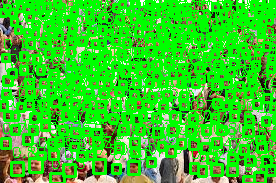

In [29]:
import cv2
from google.colab.patches import cv2_imshow

# Load image
img = cv2.imread("images.jpg")

# Draw predictions
for pred in result["predictions"]:
    x, y, w, h = pred["x"], pred["y"], pred["width"], pred["height"]
    confidence = pred["confidence"]

    # Calculate top-left and bottom-right points
    x1 = int(x - w / 2)
    y1 = int(y - h / 2)
    x2 = int(x + w / 2)
    y2 = int(y + h / 2)

    # Draw rectangle and label
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, f'{confidence:.2f}', (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

# Show image
cv2_imshow(img)
cv2.waitKey(0)
cv2.destroyAllWindows()